In [1]:
# only few python packages are required:


import numpy as np  # working with arrays
import xarray as xr  # working with xarrays
import xrscipy.signal as dsp  # scipy for xarrays
#import xrscipy.signal.extra as dsp_extra
import matplotlib.pyplot as plt  # creating plots
import pandas as pd  # working with padnas frames, loading data from golem homepage
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, WhiteKernel
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from matplotlib.colors import LinearSegmentedColormap
#from scipy.integrate import simps
import requests
from io import StringIO
import matplotlib.lines as mlines
from pathlib import Path

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, message="Predicted variances smaller than 0. Setting those variances to 0.")
warnings.filterwarnings("ignore", category=RuntimeWarning)


%matplotlib notebook

# following code is used to predefine fonts styles and sizes in all the plots
from matplotlib import rc,rcParams

rc('font', weight='bold')
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams.update({'font.size': 16, 'axes.labelsize':18})


import python_zapocet_funkce


In [2]:
# Define all shotlists and their respective radial positions (rs)


shotlist = [
    51820, 51821, 51822, 51823, 51824, 51825, 51826, 51827, 51828, 51829, 51830, 51831, 51832, 51833, 51834
]
rs = [98, 94, 90, 86, 82, 78, 74, 70, 66, 62, 58, 54, 50, 46, 42]


# Define constants for Te analysis
alpha = 2.0
BPP_alpha = 0.9
Te_shift = 0.5

# voltage divider on circuit
R_LP = 100
R_BPP = 100

# time binning
step_phi = 2

C_min_phi=1e-2
C_max_phi=1e3
RBF_min_phi=2e1
RBF_max_phi=2e2

noise_min = 1e-4
noise_max = 1e-1

# number of realizations
n_samples = 20


color_map = LinearSegmentedColormap.from_list("custom_blue_red", ["blue", "red"])

C:\Users\kryst\AppData\Local\Temp\ipykernel_17256\2201554475.py:16: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  python_zapocet_funkce.plot_er_discrete(ax2, xr.concat(Ers_mean_discrete, dim='t'), xr.concat(Ers_ci_lower_discrete, dim='t'), xr.concat(Ers_ci_upper_discrete, dim='t'), t_bins_phi, step_phi, t1, to_cycle_phi)
C:\Users\kryst\AppData\Local\Temp\ipykernel_17256\2201554475.py:16: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new de

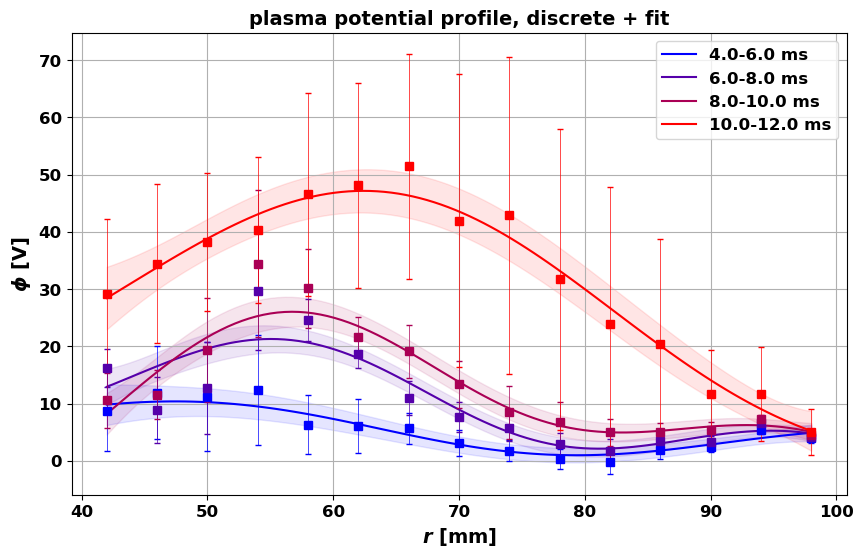

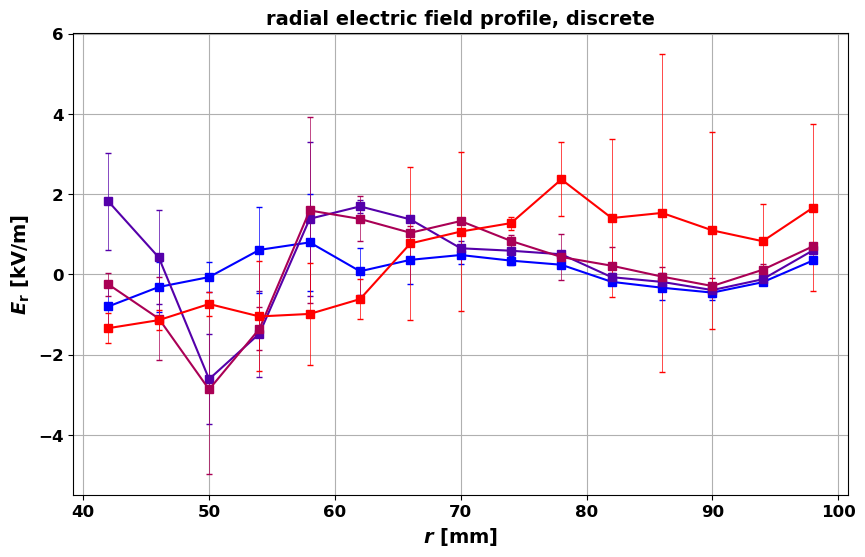

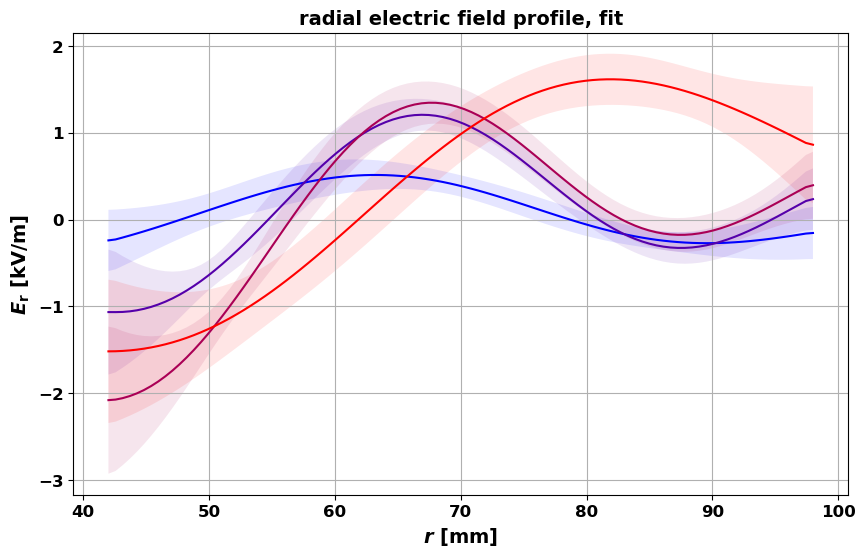

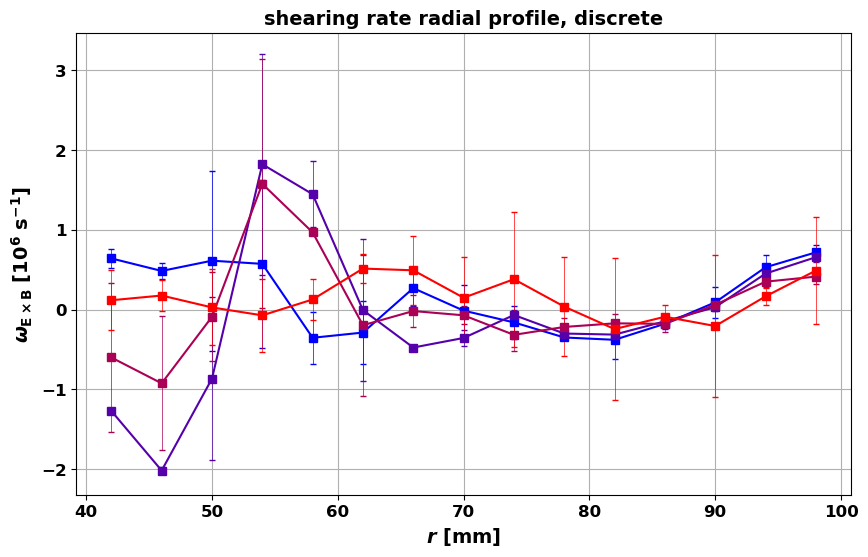

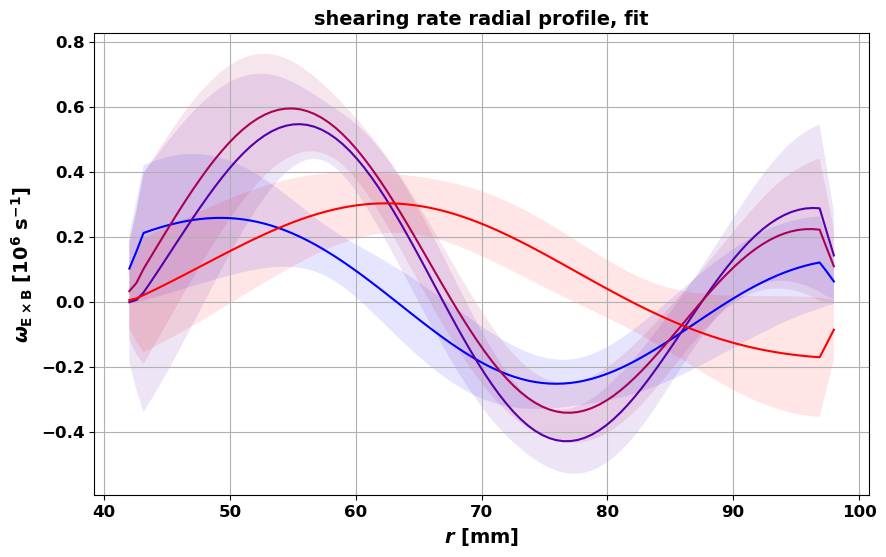

In [3]:
t1, t2 = python_zapocet_funkce.get_plasma_times(shotlist)

ds_mean_phi, ds_std_phi, t_bins_phi = python_zapocet_funkce.process_dataset(shotlist, rs, alpha, Te_shift, BPP_alpha, R_BPP, R_LP, t1, t2, step_phi)
to_cycle_phi = ds_mean_phi.t_bins.size

Ers_mean_fit, Ers_ci_lower_fit, Ers_ci_upper_fit, v_pol_mean_fit, v_pol_ci_lower_fit, v_pol_ci_upper_fit, omega_s_mean_fit, omega_s_ci_lower_fit, omega_s_ci_upper_fit, all_phi_values_fit, all_phi_errors_fit = python_zapocet_funkce.compute_phi_Er_vpol_omega_s_fit(ds_mean_phi, ds_std_phi, to_cycle_phi, C_min_phi, C_max_phi, RBF_min_phi, RBF_max_phi, noise_min, noise_max, n_samples)
Ers_mean_discrete, Ers_ci_lower_discrete, Ers_ci_upper_discrete, v_pol_mean_discrete, v_pol_ci_lower_discrete, v_pol_ci_upper_discrete, omega_s_mean_discrete, omega_s_ci_lower_discrete, omega_s_ci_upper_discrete, all_phi_values_discrete, all_phi_errors_discrete = python_zapocet_funkce.compute_phi_Er_vpol_omega_s_discrete(ds_mean_phi, ds_std_phi, to_cycle_phi)

fig, ax1 = plt.subplots(figsize=(10, 6))
fig, ax2 = plt.subplots(figsize=(10, 6))
fig, ax3 = plt.subplots(figsize=(10, 6))
fig, ax4 = plt.subplots(figsize=(10, 6))
fig, ax5 = plt.subplots(figsize=(10, 6))

python_zapocet_funkce.plot_phi_discrete_and_fit(ax1, ds_mean_phi, ds_std_phi, t_bins_phi, step_phi, t1, to_cycle_phi, C_min_phi, C_max_phi, RBF_min_phi, RBF_max_phi,noise_min, noise_max, n_samples, color_map)
python_zapocet_funkce.plot_er_discrete(ax2, xr.concat(Ers_mean_discrete, dim='t'), xr.concat(Ers_ci_lower_discrete, dim='t'), xr.concat(Ers_ci_upper_discrete, dim='t'), t_bins_phi, step_phi, t1, to_cycle_phi)
python_zapocet_funkce.plot_er_fit(ax3, xr.concat(Ers_mean_fit, dim='t'), xr.concat(Ers_ci_lower_fit, dim='t'), xr.concat(Ers_ci_upper_fit, dim='t'), t_bins_phi, step_phi, t1, to_cycle_phi)
python_zapocet_funkce.plot_omega_shearing_discrete(ax4, xr.concat(omega_s_mean_discrete, dim='t'), xr.concat(omega_s_ci_lower_discrete, dim='t'), xr.concat(omega_s_ci_upper_discrete, dim='t'), t_bins_phi, step_phi, t1, to_cycle_phi)
python_zapocet_funkce.plot_omega_shearing_fit(ax5, xr.concat(omega_s_mean_fit, dim='t'), xr.concat(omega_s_ci_lower_fit, dim='t'), xr.concat(omega_s_ci_upper_fit, dim='t'), t_bins_phi, step_phi, t1, to_cycle_phi)
plt.show()